In [107]:
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

In [108]:
pre_process_df = pd.read_csv("../../data/fe/featured_properties.csv")
pre_process_df

,property_id,property_type,link,society,sector,price_in_cr,price_per_sqft,areawithtype,plot_area,super_built_up_area,...,study_room,servant_room,store_room,pooja_room,others,facing,furnishing_type,age_possession_category,features,luxury_score
0,F84562904,Independent Builder Floor,https://www.99acres.com/4-bhk-bedroom-independ...,"sushant lok phase 1, gurgaon",sector 43,3.75,13883,"2,701 sqft (251 sqm) Super Built-up Area",NaN,2701.0,...,0,1,0,0,1,south-east,Semi-Furnished,New Property,"['Feng Shui / Vaastu Compliant', 'Water purifi...",0.803312
1,K84166766,Independent House,https://www.99acres.com/5-bhk-bedroom-independ...,"sohna road, gurgaon",sector 48,0.75,4167,1800 sqft (167.23 sqm) Built-up Area,NaN,NaN,...,0,0,0,0,0,not available,Unfurnished,Undefined,NaN,0.000000
2,F83288710,Independent House,https://www.99acres.com/4-bhk-bedroom-independ...,tata primanti,sector 72,8.50,18888,4500 sqft (418.06 sqm) Plot Area,4500.0,NaN,...,0,1,0,0,0,east,Unfurnished,Relatively New,"['Water purifier', 'Centrally Air Conditioned'...",1.364912
3,Q78848665,Flat,https://www.99acres.com/3-bhk-bedroom-apartmen...,dlf ridgewood estate,sector 28,2.95,21532,"1,370 sqft (127 sqm) Super Built-up Area",NaN,1370.0,...,0,0,0,0,0,not available,Unfurnished,Old Property,"['Feng Shui / Vaastu Compliant', 'Intercom Fac...",0.079055
4,G81994310,Independent House,https://www.99acres.com/3-bhk-bedroom-independ...,"behrampur, gurgaon",sector 71,0.41,3927,1044 sqft (96.99 sqm) Plot Area,1044.0,NaN,...,0,0,0,0,0,north-west,Unfurnished,Relatively New,['Water Storage'],0.127547
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5969,A84830038,Independent House,https://www.99acres.com/6-bhk-bedroom-independ...,"sector 46, gurgaon",sector 46,5.15,35542,1449 sqft (134.62 sqm) Plot Area,1449.0,NaN,...,0,0,0,1,0,north-east,Unfurnished,Old Property,"['Water Storage', 'Recently Renovated', 'Natur...",0.742970
5970,V85221106,Independent Builder Floor,https://www.99acres.com/5-bhk-bedroom-independ...,dlf phase 1 ultra luxury builder floors,sector 26,8.75,15909,"5,500 sqft (511 sqm) Carpet Area",NaN,NaN,...,1,1,1,1,0,north,Semi-Furnished,Relatively New,"['Security / Fire Alarm', 'Feng Shui / Vaastu ...",0.897896
5971,I85247572,Independent Builder Floor,https://www.99acres.com/4-bhk-bedroom-independ...,dlf luxury builder floors,sector 25,5.55,14605,"3,800 sqft (353 sqm) Carpet Area",NaN,NaN,...,1,1,0,1,1,north-east,Semi-Furnished,New Property,"['Water purifier', 'Centrally Air Conditioned'...",1.364912
5972,A84042908,Independent Builder Floor,https://www.99acres.com/4-bhk-bedroom-independ...,ansal api esencia,sector 67,2.61,12253,"2,430 sqft (226 sqm) Super Built-up Area",NaN,2430.0,...,0,1,0,1,1,east,Semi-Furnished,Relatively New,"['Water purifier', 'Centrally Air Conditioned'...",1.364912


### Outlier Detection and Removal

#### 1. Price In CR

In [109]:
pre_process_df['price_in_cr'].isnull().sum()

np.int64(0)

In [110]:
pre_process_df['price_in_cr'].describe()

count    5974.000000
mean        5.334066
std         5.283274
min         0.170000
25%         2.280000
50%         3.450000
75%         6.490000
max        80.000000
Name: price_in_cr, dtype: float64

In [111]:
fig = px.histogram(pre_process_df['price_in_cr'])
fig

In [112]:
fig = px.box(data_frame= pre_process_df, x='price_in_cr')
fig

In [113]:
# Identify potential outliers using IQR method

Q1 = np.quantile(pre_process_df['price_in_cr'], 0.25)
Q3 = np.quantile(pre_process_df['price_in_cr'], 0.75)

IQR = Q3 - Q1

IQR

np.float64(4.210000000000001)

In [114]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(lower_bound, upper_bound)

-4.035000000000002 12.805000000000001


In [115]:
outliers = pre_process_df[(pre_process_df['price_in_cr'] < lower_bound) | (pre_process_df['price_in_cr'] > upper_bound)]
outliers

,property_id,property_type,link,society,sector,price_in_cr,price_per_sqft,areawithtype,plot_area,super_built_up_area,...,study_room,servant_room,store_room,pooja_room,others,facing,furnishing_type,age_possession_category,features,luxury_score
10,B83901356,Independent House,https://www.99acres.com/5-bhk-bedroom-independ...,"malibu town, gurgaon",sector 47,15.00,33333,4500 sqft (418.06 sqm) Plot Area,4500.0,NaN,...,1,1,1,1,0,north-west,Semi-Furnished,Moderately Old,"['Centrally Air Conditioned', 'Water purifier'...",1.364912
17,I80507765,Independent House,https://www.99acres.com/3-bhk-bedroom-independ...,sushant lok phase 1,sector 43,20.90,77407,2700 sqft (250.84 sqm) Built-up Area,NaN,NaN,...,1,1,0,1,0,not available,Unfurnished,Relatively New,"['Security / Fire Alarm', 'High Ceiling Height...",0.585373
34,N40465305,Flat,https://www.99acres.com/4-bhk-bedroom-apartmen...,dlf the crest,sector 54,18.05,57926,"3,116 sqft (289 sqm) Super Built-up Area",NaN,3116.0,...,1,1,1,1,1,east,Semi-Furnished,Relatively New,"['Feng Shui / Vaastu Compliant', 'Security / F...",0.127547
37,P84990466,Independent House,https://www.99acres.com/4-bhk-bedroom-independ...,"sector 46, gurgaon",sector 46,15.00,33333,4500 sqft (418.06 sqm) Plot Area,4500.0,NaN,...,0,0,0,0,0,not available,Unfurnished,Old Property,NaN,0.000000
40,R84139386,Independent House,https://www.99acres.com/8-bhk-bedroom-independ...,"dlf phase 2, gurgaon",sector 25,18.00,40000,4500 sqft (418.06 sqm) Plot Area,4500.0,NaN,...,1,1,0,1,1,north,Semi-Furnished,Relatively New,"['Feng Shui / Vaastu Compliant', 'Private Gard...",0.881387
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5914,A83163028,Independent House,https://www.99acres.com/5-bhk-bedroom-independ...,international city by sobha phase 2,sector 109,15.00,41667,3600 sqft (334.45 sqm) Plot Area | 3582 sqft (...,3600.0,NaN,...,1,1,1,1,0,north-east,Unfurnished,Relatively New,"['Water purifier', 'Security / Fire Alarm', 'F...",1.327400
5917,V82811486,Flat,https://www.99acres.com/4-bhk-bedroom-apartmen...,salcon the verandas,sector 54,19.85,33661,"5,986 sqft (556 sqm) Super Built-up Area",NaN,5986.0,...,0,1,0,1,0,north-west,Furnished,Old Property,"['Centrally Air Conditioned', 'Water purifier'...",1.364912
5919,N84063534,Independent House,https://www.99acres.com/9-bhk-bedroom-independ...,luxurious villa 12mtr east facing park facing,sector 24,17.00,37778,4500 sqft (418.06 sqm) Plot Area,4500.0,NaN,...,1,1,1,1,0,east,Furnished,Relatively New,"['Feng Shui / Vaastu Compliant', 'Private Gard...",0.887775
5936,I84167596,Independent House,https://www.99acres.com/5-bhk-bedroom-independ...,international city by sobha phase 2,sector 109,14.00,38889,3600 sqft (334.45 sqm) Plot Area,3600.0,NaN,...,0,1,1,0,0,north,Semi-Furnished,Relatively New,"['Feng Shui / Vaastu Compliant', 'Private Gard...",1.145334


In [116]:
outliers.describe()

,price_in_cr,price_per_sqft,plot_area,super_built_up_area,built_up_area,carpet_area,bedrooms,bathrooms,floornum,study_room,servant_room,store_room,pooja_room,others,luxury_score
count,516.000000,516.000000,434.000000,36.000000,107.000000,83.000000,516.000000,516.000000,496.000000,516.000000,516.000000,516.000000,516.000000,516.000000,516.000000
mean,18.889709,49511.358527,4556.564516,4923.361111,6507.757009,6296.650602,6.317829,7.005814,3.796371,0.674419,0.912791,0.519380,0.736434,0.151163,0.993234
std,6.539067,58155.414252,2260.522169,1186.585694,7152.615928,8727.955247,4.305760,4.392178,4.456849,0.469046,0.282415,0.500109,0.440994,0.358555,0.386963
min,12.840000,2091.000000,350.000000,2686.000000,2200.000000,2000.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,14.837500,33333.000000,3240.000000,4126.000000,4050.000000,3301.500000,5.000000,5.000000,2.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.881387
50%,17.000000,41666.500000,4500.000000,4817.000000,6000.000000,4200.000000,5.000000,6.000000,3.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.074407
75%,21.000000,52469.000000,4518.000000,6000.000000,7650.000000,6950.000000,6.000000,7.000000,3.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.363971
max,80.000000,619469.000000,29160.000000,7000.000000,76500.000000,61200.000000,48.000000,50.000000,41.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.364912


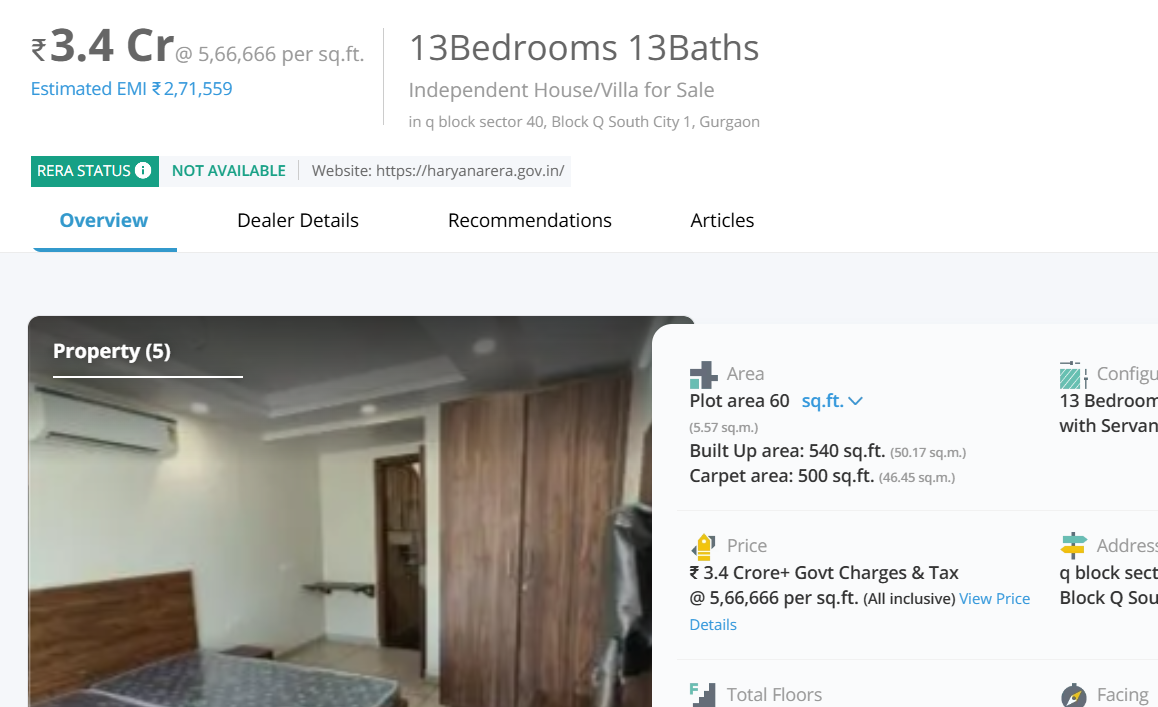

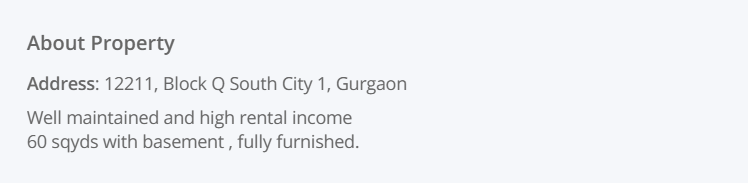

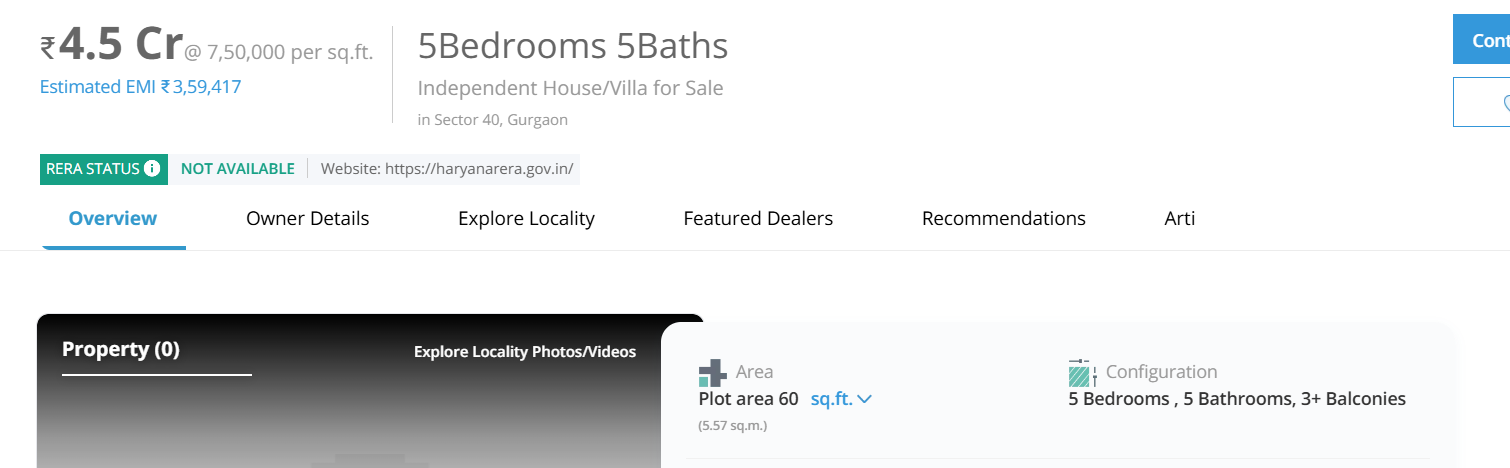

### 2. Total Area Sqft

In [119]:
def create_area_missing_flags(df):

    df = df.copy()

    area_cols = [
        'super_built_up_area',
        'built_up_area',
        'carpet_area',
        'plot_area'
    ]

    for col in area_cols:
        df[f"{col}_missing"] = df[col].isna().astype(int)

    return df

pre_process_df = create_area_missing_flags(pre_process_df)

In [120]:
def create_area_missing_flags(df):

    df = df.copy()

    area_cols = [
        'super_built_up_area',
        'built_up_area',
        'carpet_area',
        'plot_area'
    ]

    for col in area_cols:
        df[f"{col}_missing"] = df[col].isna().astype(int)

    return df

pre_process_df = create_area_missing_flags(pre_process_df)

In [121]:
pre_process_df

,property_id,property_type,link,society,sector,price_in_cr,price_per_sqft,areawithtype,plot_area,super_built_up_area,...,others,facing,furnishing_type,age_possession_category,features,luxury_score,super_built_up_area_missing,built_up_area_missing,carpet_area_missing,plot_area_missing
0,F84562904,Independent Builder Floor,https://www.99acres.com/4-bhk-bedroom-independ...,"sushant lok phase 1, gurgaon",sector 43,3.75,13883,"2,701 sqft (251 sqm) Super Built-up Area",NaN,2701.0,...,1,south-east,Semi-Furnished,New Property,"['Feng Shui / Vaastu Compliant', 'Water purifi...",0.803312,0,1,1,1
1,K84166766,Independent House,https://www.99acres.com/5-bhk-bedroom-independ...,"sohna road, gurgaon",sector 48,0.75,4167,1800 sqft (167.23 sqm) Built-up Area,NaN,NaN,...,0,not available,Unfurnished,Undefined,NaN,0.000000,1,0,1,1
2,F83288710,Independent House,https://www.99acres.com/4-bhk-bedroom-independ...,tata primanti,sector 72,8.50,18888,4500 sqft (418.06 sqm) Plot Area,4500.0,NaN,...,0,east,Unfurnished,Relatively New,"['Water purifier', 'Centrally Air Conditioned'...",1.364912,1,1,1,0
3,Q78848665,Flat,https://www.99acres.com/3-bhk-bedroom-apartmen...,dlf ridgewood estate,sector 28,2.95,21532,"1,370 sqft (127 sqm) Super Built-up Area",NaN,1370.0,...,0,not available,Unfurnished,Old Property,"['Feng Shui / Vaastu Compliant', 'Intercom Fac...",0.079055,0,1,1,1
4,G81994310,Independent House,https://www.99acres.com/3-bhk-bedroom-independ...,"behrampur, gurgaon",sector 71,0.41,3927,1044 sqft (96.99 sqm) Plot Area,1044.0,NaN,...,0,north-west,Unfurnished,Relatively New,['Water Storage'],0.127547,1,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5969,A84830038,Independent House,https://www.99acres.com/6-bhk-bedroom-independ...,"sector 46, gurgaon",sector 46,5.15,35542,1449 sqft (134.62 sqm) Plot Area,1449.0,NaN,...,0,north-east,Unfurnished,Old Property,"['Water Storage', 'Recently Renovated', 'Natur...",0.742970,1,1,1,0
5970,V85221106,Independent Builder Floor,https://www.99acres.com/5-bhk-bedroom-independ...,dlf phase 1 ultra luxury builder floors,sector 26,8.75,15909,"5,500 sqft (511 sqm) Carpet Area",NaN,NaN,...,0,north,Semi-Furnished,Relatively New,"['Security / Fire Alarm', 'Feng Shui / Vaastu ...",0.897896,1,1,0,1
5971,I85247572,Independent Builder Floor,https://www.99acres.com/4-bhk-bedroom-independ...,dlf luxury builder floors,sector 25,5.55,14605,"3,800 sqft (353 sqm) Carpet Area",NaN,NaN,...,1,north-east,Semi-Furnished,New Property,"['Water purifier', 'Centrally Air Conditioned'...",1.364912,1,1,0,1
5972,A84042908,Independent Builder Floor,https://www.99acres.com/4-bhk-bedroom-independ...,ansal api esencia,sector 67,2.61,12253,"2,430 sqft (226 sqm) Super Built-up Area",NaN,2430.0,...,1,east,Semi-Furnished,Relatively New,"['Water purifier', 'Centrally Air Conditioned'...",1.364912,0,1,1,1


In [122]:
def create_primary_area(df):

    df = df.copy()

    df["total_area_sqft"] = np.nan

    flat_mask = df["property_type"].isin(
        ["Flat", "Independent Builder Floor"]
    )

    df.loc[flat_mask, "total_area_sqft"] = \
        df.loc[flat_mask, "super_built_up_area"]

    house_mask = df["property_type"] == "Independent House"

    df.loc[house_mask, "total_area_sqft"] = \
        df.loc[house_mask, "plot_area"]

    return df

pre_process_df = create_primary_area(pre_process_df)

In [123]:
pre_process_df

,property_id,property_type,link,society,sector,price_in_cr,price_per_sqft,areawithtype,plot_area,super_built_up_area,...,facing,furnishing_type,age_possession_category,features,luxury_score,super_built_up_area_missing,built_up_area_missing,carpet_area_missing,plot_area_missing,total_area_sqft
0,F84562904,Independent Builder Floor,https://www.99acres.com/4-bhk-bedroom-independ...,"sushant lok phase 1, gurgaon",sector 43,3.75,13883,"2,701 sqft (251 sqm) Super Built-up Area",NaN,2701.0,...,south-east,Semi-Furnished,New Property,"['Feng Shui / Vaastu Compliant', 'Water purifi...",0.803312,0,1,1,1,2701.0
1,K84166766,Independent House,https://www.99acres.com/5-bhk-bedroom-independ...,"sohna road, gurgaon",sector 48,0.75,4167,1800 sqft (167.23 sqm) Built-up Area,NaN,NaN,...,not available,Unfurnished,Undefined,NaN,0.000000,1,0,1,1,NaN
2,F83288710,Independent House,https://www.99acres.com/4-bhk-bedroom-independ...,tata primanti,sector 72,8.50,18888,4500 sqft (418.06 sqm) Plot Area,4500.0,NaN,...,east,Unfurnished,Relatively New,"['Water purifier', 'Centrally Air Conditioned'...",1.364912,1,1,1,0,4500.0
3,Q78848665,Flat,https://www.99acres.com/3-bhk-bedroom-apartmen...,dlf ridgewood estate,sector 28,2.95,21532,"1,370 sqft (127 sqm) Super Built-up Area",NaN,1370.0,...,not available,Unfurnished,Old Property,"['Feng Shui / Vaastu Compliant', 'Intercom Fac...",0.079055,0,1,1,1,1370.0
4,G81994310,Independent House,https://www.99acres.com/3-bhk-bedroom-independ...,"behrampur, gurgaon",sector 71,0.41,3927,1044 sqft (96.99 sqm) Plot Area,1044.0,NaN,...,north-west,Unfurnished,Relatively New,['Water Storage'],0.127547,1,1,1,0,1044.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5969,A84830038,Independent House,https://www.99acres.com/6-bhk-bedroom-independ...,"sector 46, gurgaon",sector 46,5.15,35542,1449 sqft (134.62 sqm) Plot Area,1449.0,NaN,...,north-east,Unfurnished,Old Property,"['Water Storage', 'Recently Renovated', 'Natur...",0.742970,1,1,1,0,1449.0
5970,V85221106,Independent Builder Floor,https://www.99acres.com/5-bhk-bedroom-independ...,dlf phase 1 ultra luxury builder floors,sector 26,8.75,15909,"5,500 sqft (511 sqm) Carpet Area",NaN,NaN,...,north,Semi-Furnished,Relatively New,"['Security / Fire Alarm', 'Feng Shui / Vaastu ...",0.897896,1,1,0,1,NaN
5971,I85247572,Independent Builder Floor,https://www.99acres.com/4-bhk-bedroom-independ...,dlf luxury builder floors,sector 25,5.55,14605,"3,800 sqft (353 sqm) Carpet Area",NaN,NaN,...,north-east,Semi-Furnished,New Property,"['Water purifier', 'Centrally Air Conditioned'...",1.364912,1,1,0,1,NaN
5972,A84042908,Independent Builder Floor,https://www.99acres.com/4-bhk-bedroom-independ...,ansal api esencia,sector 67,2.61,12253,"2,430 sqft (226 sqm) Super Built-up Area",NaN,2430.0,...,east,Semi-Furnished,Relatively New,"['Water purifier', 'Centrally Air Conditioned'...",1.364912,0,1,1,1,2430.0


In [124]:
pre_process_df['total_area_sqft'].isna().sum()

np.int64(1093)

In [125]:
(pre_process_df[["super_built_up_area",
        "built_up_area",
        "carpet_area",
        "plot_area"]]
    .isna()
    .all(axis=1)
).sum()

np.int64(0)

In [126]:
def fallback_area_creation(df):

    df = df.copy()

    fallback_cols = [
        "super_built_up_area",
        "built_up_area",
        "carpet_area",
        "plot_area"
    ]

    df["total_area_sqft"] = df["total_area_sqft"].fillna(
        df[fallback_cols].median(axis=1)
    )

    return df

pre_process_df = fallback_area_creation(pre_process_df)

In [127]:
pre_process_df['total_area_sqft'].isna().sum()

np.int64(0)

In [128]:
pre_process_df['total_area_sqft'].describe()

count     5974.000000
mean      2388.412789
std       1428.918586
min         42.000000
25%       1540.000000
50%       2100.000000
75%       2812.000000
max      29160.000000
Name: total_area_sqft, dtype: float64

In [129]:
fig = px.histogram(
    pre_process_df['total_area_sqft'],
    histnorm="density",
    title = "Distribution of total_area_sqft" 
)
fig.show()

In [130]:
pre_process_df.groupby("property_type")["total_area_sqft"].describe()

,count,mean,std,min,25%,50%,75%,max
property_type,,,,,,,,
Flat,2460.0,2122.227236,878.918793,456.0,1625.0,1930.0,2408.5,10000.0
Independent Builder Floor,1252.0,2586.895367,957.992921,300.0,1900.0,2430.5,3078.0,7659.0
Independent House,2262.0,2568.039788,1978.592991,42.0,1080.0,2250.0,3240.0,29160.0


In [131]:
pre_process_df.groupby("property_type")["total_area_sqft"].skew()

property_type
Flat                         2.141001
Independent Builder Floor    0.813185
Independent House            2.406704
Name: total_area_sqft, dtype: float64

In [132]:
# Calculate IQR for total_area_sqft

Q1 = pre_process_df['total_area_sqft'].quantile(0.25)
Q3 = pre_process_df['total_area_sqft'].quantile(0.75)
IQR = Q3 - Q1

# Outlier bounds

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 3 * IQR

print(lower_bound, upper_bound)

-368.0 6628.0


In [133]:
# Calculate IQR for total_area_sqft

Q1 = pre_process_df['total_area_sqft'].quantile(0.25)
Q3 = pre_process_df['total_area_sqft'].quantile(0.75)
IQR = Q3 - Q1

# Outlier bounds

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 3 * IQR

print(lower_bound, upper_bound)

-368.0 6628.0


In [134]:
outliers_area = pre_process_df[
    (pre_process_df['total_area_sqft'] < lower_bound) |
    (pre_process_df['total_area_sqft'] > upper_bound)
]
outliers_area

,property_id,property_type,link,society,sector,price_in_cr,price_per_sqft,areawithtype,plot_area,super_built_up_area,...,facing,furnishing_type,age_possession_category,features,luxury_score,super_built_up_area_missing,built_up_area_missing,carpet_area_missing,plot_area_missing,total_area_sqft
62,N84397262,Independent House,https://www.99acres.com/6-bhk-bedroom-independ...,18 mtr wide road,sector 43,30.00,33333,9000 sqft (836.13 sqm) Plot Area,9000.0,NaN,...,north,Semi-Furnished,Moderately Old,"['Centrally Air Conditioned', 'Water purifier'...",1.364912,1,1,1,0,9000.0
91,H82779500,Flat,https://www.99acres.com/5-bhk-bedroom-apartmen...,adani m2k oyster grande,sector 102,9.40,12906,"7,283 sqft (677 sqm) Super Built-up Area",NaN,7283.0,...,north-east,Unfurnished,New Property,"['Centrally Air Conditioned', 'Water purifier'...",1.364912,0,1,1,1,7283.0
199,C84071252,Independent House,https://www.99acres.com/5-bhk-bedroom-independ...,emaar mgf marbella,sector 66,22.00,27093,8120 sqft (754.37 sqm) Plot Area | 8120 sqft (...,8120.0,NaN,...,east,Unfurnished,Relatively New,"['Feng Shui / Vaastu Compliant', 'Private Gard...",1.119801,1,0,1,0,8120.0
211,D84694170,Independent House,https://www.99acres.com/6-bhk-bedroom-independ...,ultra-luxury villa,sector 43,17.00,17894,9500 sqft (882.58 sqm) Built-up Area | 8500 sq...,NaN,NaN,...,east,Semi-Furnished,Relatively New,"['Centrally Air Conditioned', 'Water purifier'...",1.364912,1,0,0,1,9000.0
264,W76422111,Independent House,https://www.99acres.com/5-bhk-bedroom-independ...,vipul tatvam villa,sector 48,21.00,31028,6768 sqft (628.77 sqm) Plot Area,6768.0,NaN,...,north-east,Semi-Furnished,Relatively New,"['Centrally Air Conditioned', 'Security / Fire...",1.360033,1,1,1,0,6768.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5595,Q84465034,Independent House,https://www.99acres.com/4-bhk-bedroom-independ...,orchid petals,sector 49,19.00,27417,6930 sqft (643.82 sqm) Plot Area | 3960 sqft (...,6930.0,NaN,...,east,Unfurnished,Moderately Old,"['Private Garden / Terrace', 'High Ceiling Hei...",1.074390,1,1,0,0,6930.0
5602,G83969348,Independent House,https://www.99acres.com/4-bhk-bedroom-independ...,tata primanti,sector 72,12.00,17142,7000 sqft (650.32 sqm) Plot Area,7000.0,NaN,...,east,Unfurnished,Relatively New,"['Feng Shui / Vaastu Compliant', 'Private Gard...",0.881387,1,1,1,0,7000.0
5641,D84756666,Independent House,https://www.99acres.com/5-bhk-bedroom-independ...,vipul tatvam villa,sector 48,19.75,29259,6750 sqft (627.1 sqm) Plot Area,6750.0,NaN,...,north-east,Semi-Furnished,Old Property,"['Feng Shui / Vaastu Compliant', 'Private Gard...",1.119801,1,1,1,0,6750.0
5653,M77906185,Independent House,https://www.99acres.com/5-bhk-bedroom-independ...,international city by sobha phase 1,sector 109,18.00,24556,7330 sqft (680.98 sqm) Built-up Area,NaN,NaN,...,north-east,Unfurnished,Relatively New,"['Feng Shui / Vaastu Compliant', 'Private Gard...",1.119801,1,0,1,1,7330.0


In [135]:
extreme = pre_process_df[pre_process_df["total_area_sqft"] >= 15000]
extreme[["link","property_type","total_area_sqft","price_in_cr","price_per_sqft","sector"]]

,link,property_type,total_area_sqft,price_in_cr,price_per_sqft,sector
866,https://www.99acres.com/7-bhk-bedroom-independ...,Independent House,15000.0,37.0,24666,sector 26
5114,https://www.99acres.com/5-bhk-bedroom-independ...,Independent House,29160.0,15.5,5315,sector 50


In [136]:
pre_process_df = pre_process_df[pre_process_df["total_area_sqft"] <= 15000]

In [137]:
fig = px.histogram(
    pre_process_df['total_area_sqft'],
    histnorm="density",
    title ="Distribution of total area sqft after removal of high values outliers"
)
fig.show()

### Price Per Sqft

In [138]:
pre_process_df['price_per_sqft'].describe()

count      5973.000000
mean      24533.423405
std       35098.161371
min        1815.000000
25%       12391.000000
50%       16244.000000
75%       27296.000000
max      750000.000000
Name: price_per_sqft, dtype: float64

In [139]:
fig = px.box(data_frame= pre_process_df, x='price_per_sqft')
fig

In [140]:
fig = px.histogram(
    pre_process_df['price_per_sqft'],
    histnorm="density"  
)
fig.show()

In [141]:
pre_process_df[pre_process_df["price_per_sqft"] > 100000][
    ["property_type","total_area_sqft","bedrooms","price_in_cr","price_per_sqft"]
]

,property_type,total_area_sqft,bedrooms,price_in_cr,price_per_sqft
13,Independent House,160.0,2,5.50,458333
147,Independent House,158.0,3,1.79,113291
170,Independent House,360.0,6,20.98,582777
219,Independent House,3250.0,5,2.00,333333
246,Independent House,345.0,4,10.00,289855
...,...,...,...,...,...
5245,Independent House,200.0,21,2.70,135000
5371,Independent House,360.0,5,12.49,346944
5448,Independent House,168.0,5,5.25,312500
5451,Independent House,68.0,10,1.60,235294


In [142]:
pre_process_df = pre_process_df[pre_process_df["price_per_sqft"] < 100000]

### Area vs Bedrooms

<Figure size 1200x500 with 0 Axes>

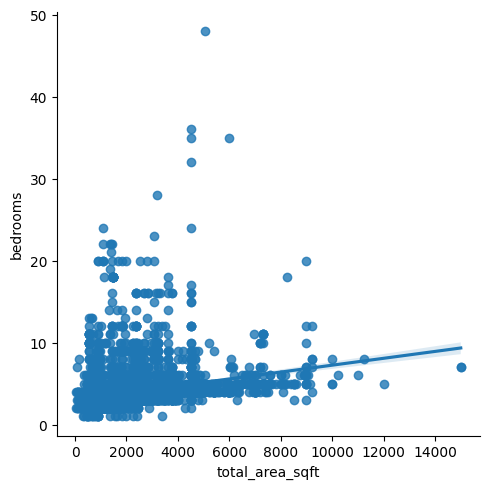

In [143]:
plt.figure(figsize=(12,5))
sns.lmplot(data= pre_process_df, x= 'total_area_sqft', y = 'bedrooms')

H72701303 - 540 sqft (50.17 sqm) Plot Area - 10 BHK Indepedent House 

X83996242 - 594 sqft (55.18 sqm) Plot Area - 11 BHK Indepdent house

At first glance, the property data appears genuine. However, certain records raise strong suspicion. Practically, it is extremely difficult to fit 11 bedrooms into such a small space, which suggests this entry could be erroneous or misleading.

Instead of analyzing each attribute in isolation (like price_per_sqft, area, price, or bedrooms), it is more meaningful to perform bivariate analysis — comparing two attributes together. In this case, analyzing area vs. bedroom count would help us identify unrealistic or extreme cases where the relationship between area and bedroom size does not make sense.

The rationale is that while individual values may look plausible on their own, the combination of features often reveals hidden outliers. For example:

A small area with an unusually high number of bedrooms (impractical).

A very large area with too few bedrooms (possibly data entry error).

By capturing such “dangerous” or inconsistent points through multivariate validation, we can better clean the dataset and improve the reliability of downstream metrics like price_per_sqft.

#### Bi-Variate Outlier Detection

In [144]:
pre_process_df["area_per_bedroom"] = (
    pre_process_df["total_area_sqft"] /
    pre_process_df["bedrooms"]
)

In [145]:

print("Area per bedroom distribution:")
print(pre_process_df["area_per_bedroom"].describe().round(0))

print("\nProperties below 200 sqft/bedroom:")
print(pre_process_df[pre_process_df["area_per_bedroom"] < 200][["total_area_sqft", "bedrooms", "area_per_bedroom"]].head(10))

print("\nProperties below 275 sqft/bedroom:")
print(pre_process_df[pre_process_df["area_per_bedroom"] < 275][["total_area_sqft", "bedrooms", "area_per_bedroom"]].head(10))

Area per bedroom distribution:
count    5899.0
mean      643.0
std       290.0
min        13.0
25%       498.0
50%       633.0
75%       766.0
max      3375.0
Name: area_per_bedroom, dtype: float64

Properties below 200 sqft/bedroom:
     total_area_sqft  bedrooms  area_per_bedroom
14             225.0         2        112.500000
48             918.0         5        183.600000
52            1669.0        20         83.450000
102            245.0         3         81.666667
118            963.0         9        107.000000
132            540.0         8         67.500000
153            594.0         7         84.857143
187            540.0        10         54.000000
193           1449.0        12        120.750000
194            900.0         6        150.000000

Properties below 275 sqft/bedroom:
     total_area_sqft  bedrooms  area_per_bedroom
14             225.0         2        112.500000
21            1080.0         4        270.000000
48             918.0         5        183.60

In [146]:
# Run this in notebook to see impact
pre_process_df["area_per_bedroom"] = pre_process_df["total_area_sqft"] / pre_process_df["bedrooms"]

below_200 = pre_process_df[pre_process_df["area_per_bedroom"] < 200]
below_300 = pre_process_df[pre_process_df["area_per_bedroom"] < 300]

print(f"Removed with min_ratio=200 : {len(below_200)} properties")
print(f"Removed with min_ratio=300 : {len(below_300)} properties")
print(f"Extra rows removed by raising to 300: {len(below_300) - len(below_200)}")

print("\nExtra properties removed by raising threshold to 300:")
extra = pre_process_df[(pre_process_df["area_per_bedroom"] >= 200) & (pre_process_df["area_per_bedroom"] < 300)]
extra[["total_area_sqft", "bedrooms", "area_per_bedroom"]].sort_values("area_per_bedroom")

Removed with min_ratio=200 : 370 properties
Removed with min_ratio=300 : 688 properties
Extra rows removed by raising to 300: 318

Extra properties removed by raising threshold to 300:


,total_area_sqft,bedrooms,area_per_bedroom
73,1400.0,7,200.0
70,1800.0,9,200.0
220,1800.0,9,200.0
1066,2000.0,10,200.0
1316,1800.0,9,200.0
...,...,...,...
2605,594.0,2,297.0
4231,594.0,2,297.0
5047,1485.0,5,297.0
5179,594.0,2,297.0


In [147]:
ratio_filter        = pre_process_df["area_per_bedroom"] >= 200
high_bedroom_filter = ~((pre_process_df["bedrooms"] >= 7) & (pre_process_df["area_per_bedroom"] < 300))

removed = pre_process_df[~(ratio_filter & high_bedroom_filter)]
kept    = pre_process_df[ratio_filter & high_bedroom_filter]

print(f"Total removed : {len(removed)}")
print(f"Total kept    : {len(kept)}")

print("\nSample of what gets removed:")
display(removed[["total_area_sqft", "bedrooms", "area_per_bedroom"]].sort_values("area_per_bedroom").head(15))

print("\nSample of compact properties correctly kept:")
display(
    kept[kept["bedrooms"] <= 2]
    [["total_area_sqft", "bedrooms", "area_per_bedroom"]]
    .sort_values("area_per_bedroom")
    .head(10)
)

Total removed : 472
Total kept    : 5427

Sample of what gets removed:


,total_area_sqft,bedrooms,area_per_bedroom
2886,53.0,4,13.250000
851,95.0,7,13.571429
2035,75.0,4,18.750000
5411,42.0,2,21.000000
4516,171.0,8,21.375000
2660,99.0,4,24.750000
4029,100.0,4,25.000000
3917,100.0,4,25.000000
4532,80.0,3,26.666667
4303,108.0,4,27.000000



Sample of compact properties correctly kept:


,total_area_sqft,bedrooms,area_per_bedroom
513,400.0,2,200.0
1285,420.0,2,210.0
5046,450.0,2,225.0
718,450.0,2,225.0
4547,450.0,2,225.0
3872,450.0,2,225.0
4800,450.0,2,225.0
3326,450.0,2,225.0
2768,450.0,2,225.0
2796,450.0,2,225.0


In [148]:
# Compare old threshold vs new threshold
old_filter = pre_process_df["area_per_bedroom"] >= 200
new_filter = (pre_process_df["area_per_bedroom"] >= 250) & \
             ~((pre_process_df["bedrooms"] >= 7) & (pre_process_df["area_per_bedroom"] < 300))

print(f"Removed with old threshold (200) : {(~old_filter).sum()}")
print(f"Removed with new threshold (250) : {(~new_filter).sum()}")
print(f"Extra rows removed               : {(~new_filter).sum() - (~old_filter).sum()}")

# What extra rows does 250 remove that 200 didn't?
extra_removed = pre_process_df[old_filter & ~new_filter]
print(f"\nExtra properties removed by raising to 250:")
extra_removed[["total_area_sqft", "bedrooms", "area_per_bedroom"]]\
    .sort_values("area_per_bedroom")\
    .head(20)

Removed with old threshold (200) : 370
Removed with new threshold (250) : 589
Extra rows removed               : 219

Extra properties removed by raising to 250:


,total_area_sqft,bedrooms,area_per_bedroom
70,1800.0,9,200.0
73,1400.0,7,200.0
220,1800.0,9,200.0
513,400.0,2,200.0
919,600.0,3,200.0
1066,2000.0,10,200.0
1316,1800.0,9,200.0
1970,3600.0,18,200.0
3234,1800.0,9,200.0
4100,1800.0,9,200.0


In [149]:
house_df = pre_process_df[pre_process_df["property_type"] == "Independent House"].copy()
house_df["area_per_bedroom"] = house_df["total_area_sqft"] / house_df["bedrooms"]

print("Area per bedroom — Independent Houses only:")
print(house_df["area_per_bedroom"].describe().round(0))

print("\nHow many houses would be flagged at threshold 290?")
flagged = house_df[house_df["area_per_bedroom"] < 290]
print(f"{len(flagged)} out of {len(house_df)} houses ({len(flagged)/len(house_df)*100:.1f}%)")

Area per bedroom — Independent Houses only:
count    2189.0
mean      556.0
std       395.0
min        13.0
25%       255.0
50%       484.0
75%       750.0
max      3375.0
Name: area_per_bedroom, dtype: float64

How many houses would be flagged at threshold 290?
646 out of 2189 houses (29.5%)


In [151]:
def remove_area_bedroom_ratio_outliers(
    df: pd.DataFrame,
    min_ratio: int = 200,          

):
    df = df.copy()
    before = df.shape[0]

    df["area_per_bedroom"] = df["total_area_sqft"] / df["bedrooms"]

    # Condition 1 — global minimum ratio (raised to 250)
    # Less than 250 sqft/bedroom is practically impossible
    # for any residential layout including kitchen + bathrooms
    ratio_filter = df["area_per_bedroom"] >= min_ratio

    # Condition 2 — high bedroom count filter
    # 7+ bedrooms need proportionally more space
    high_bedroom_filter = ~(
        (df["bedrooms"] >= 7) &
        (df["area_per_bedroom"] < 300)
    )

    df = df[ratio_filter & high_bedroom_filter]

    after = df.shape[0]
    # logger.info(f"Removed {before - after} implausible layout rows.")
    return df

In [152]:
pre_process_df = remove_area_bedroom_ratio_outliers(pre_process_df)

In [155]:
pre_process_df[['total_area_sqft','area_per_bedroom','bedrooms','price_in_cr','property_type']]

,total_area_sqft,area_per_bedroom,bedrooms,price_in_cr,property_type
0,2701.0,675.250000,4,3.75,Independent Builder Floor
1,1800.0,360.000000,5,0.75,Independent House
2,4500.0,1125.000000,4,8.50,Independent House
3,1370.0,456.666667,3,2.95,Flat
4,1044.0,348.000000,3,0.41,Independent House
...,...,...,...,...,...
5969,1449.0,241.500000,6,5.15,Independent House
5970,5500.0,1100.000000,5,8.75,Independent Builder Floor
5971,3800.0,950.000000,4,5.55,Independent Builder Floor
5972,2430.0,607.500000,4,2.61,Independent Builder Floor


In [156]:
pre_process_df["area_per_bedroom"].describe()

count    5427.000000
mean      685.996278
std       261.870776
min       200.000000
25%       541.666667
50%       648.000000
75%       787.500000
max      3375.000000
Name: area_per_bedroom, dtype: float64

<Figure size 1200x500 with 0 Axes>

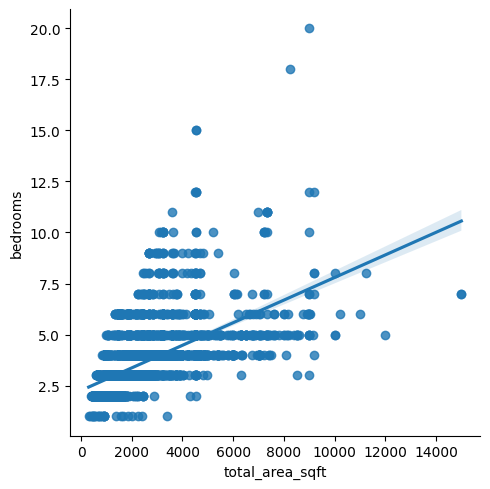

In [157]:
plt.figure(figsize=(12,5))
sns.lmplot(data= pre_process_df, x= 'total_area_sqft', y = 'bedrooms')

In [158]:
pre_process_df["area_per_bedroom"].quantile([0.01, 0.02, 0.05])

0.01    225.000
0.02    247.068
0.05    306.000
Name: area_per_bedroom, dtype: float64

In [159]:
(pre_process_df["area_per_bedroom"] < 200).sum() / pre_process_df.shape[0] * 100

np.float64(0.0)

In [160]:
pre_process_df.loc[
    pre_process_df["area_per_bedroom"] < 275,
    ["property_type","total_area_sqft","bedrooms","price_in_cr","area_per_bedroom"]
]

,property_type,total_area_sqft,bedrooms,price_in_cr,area_per_bedroom
21,Independent House,1080.0,4,7.20,270.000000
55,Independent House,1620.0,6,4.95,270.000000
77,Independent House,540.0,2,2.30,270.000000
122,Independent House,500.0,2,0.65,250.000000
168,Independent House,630.0,3,0.48,210.000000
...,...,...,...,...,...
5891,Independent House,668.0,3,0.50,222.666667
5906,Independent House,650.0,3,0.80,216.666667
5918,Independent House,1449.0,6,5.50,241.500000
5948,Independent House,1449.0,6,5.25,241.500000


<Axes: xlabel='area_per_bedroom', ylabel='price_per_sqft'>

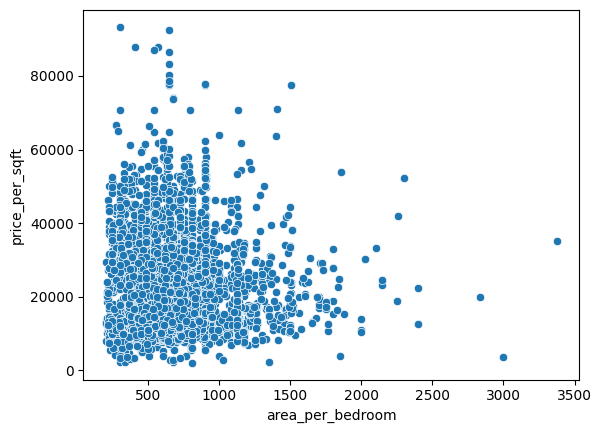

In [165]:

sns.scatterplot(
    x="area_per_bedroom",
    y="price_per_sqft",
    data=pre_process_df
)

In [166]:
fig = px.histogram(
    pre_process_df['area_per_bedroom'],
    histnorm = "density",
    title = "Distribution of area_per_bedroom after removal of outliers"
)
fig.show()

##### Bedroom

In [167]:
pre_process_df['bedrooms'].describe()

count    5427.000000
mean        3.643634
std         1.315842
min         1.000000
25%         3.000000
50%         3.000000
75%         4.000000
max        20.000000
Name: bedrooms, dtype: float64

In [168]:
pre_process_df['bedrooms'].unique()

array([ 4,  5,  3,  2,  8,  6,  9,  7,  1, 10, 12, 15, 11, 18, 20])

In [169]:
fig = px.box(
    data_frame= pre_process_df,
    x= ['bedrooms'],
)
fig.show()

In [170]:
fig = px.histogram(
    pre_process_df['bedrooms'],
    histnorm="density"
)
fig.show()

In [171]:
pre_process_df[pre_process_df['bedrooms'] > 15].sort_values('bedrooms',ascending=False)

,property_id,property_type,link,society,sector,price_in_cr,price_per_sqft,areawithtype,plot_area,super_built_up_area,...,furnishing_type,age_possession_category,features,luxury_score,super_built_up_area_missing,built_up_area_missing,carpet_area_missing,plot_area_missing,total_area_sqft,area_per_bedroom
5073,W84006436,Independent House,https://www.99acres.com/20-bhk-bedroom-indepen...,"sector 46, gurgaon",sector 46,28.0,31111,9000 sqft (836.13 sqm) Plot Area,9000.0,NaN,...,Furnished,Moderately Old,"['Water Storage', 'Visitor Parking', 'Waste Di...",0.346596,1,1,1,0,9000.0,450.000000
3104,J84426212,Independent House,https://www.99acres.com/18-bhk-bedroom-indepen...,spaze palazo,sector 69,4.1,4979,8234 sqft (764.96 sqm) Plot Area,8234.0,NaN,...,Unfurnished,New Property,NaN,0.000000,1,1,1,0,8234.0,457.444444


### Bathroom

In [172]:
pre_process_df['bathrooms'].describe()

count    5427.000000
mean        3.857933
std         1.518255
min         1.000000
25%         3.000000
50%         4.000000
75%         4.000000
max        20.000000
Name: bathrooms, dtype: float64

In [173]:
fig = px.box(
    data_frame= pre_process_df,
    x= ['bathrooms'],
)
fig.show()

In [174]:
fig = px.histogram(
    pre_process_df['bathrooms'],
    histnorm="density"
)
fig.show()

### Luxury Score 

In [177]:
pre_process_df['luxury_score'].describe()

count    5427.000000
mean        0.686920
std         0.480703
min         0.000000
25%         0.200551
50%         0.703518
75%         1.129178
max         1.364912
Name: luxury_score, dtype: float64

In [178]:
fig = px.histogram(
    pre_process_df['luxury_score'],
    histnorm="density"
)
fig.show()

<Axes: xlabel='total_area_sqft', ylabel='price_in_cr'>

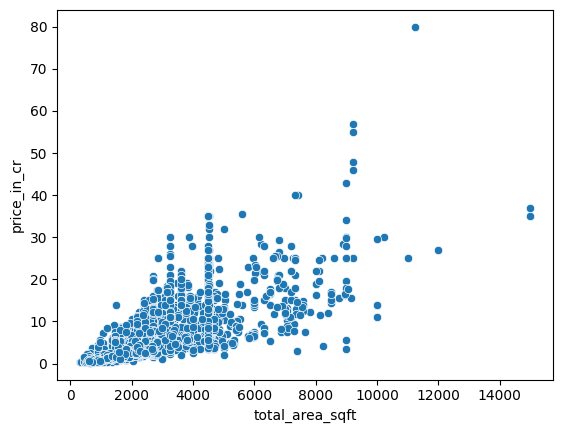

In [179]:
sns.scatterplot(x = pre_process_df['total_area_sqft'],y = pre_process_df['price_in_cr'])

In [180]:
pre_process_df.isnull().sum()

property_id                       0
property_type                     0
link                              0
society                           0
sector                            0
price_in_cr                       0
price_per_sqft                    0
areawithtype                      0
plot_area                      3856
super_built_up_area            2637
built_up_area                  4791
carpet_area                    4492
bedrooms                          0
bathrooms                         0
balcony                           0
floornum                         82
study_room                        0
servant_room                      0
store_room                        0
pooja_room                        0
others                            0
facing                            0
furnishing_type                   0
age_possession_category           0
features                        261
luxury_score                      0
super_built_up_area_missing       0
built_up_area_missing       

### FloorNum

In [181]:
pre_process_df['floornum'].describe()

count    5345.000000
mean        5.839102
std         5.894844
min        -1.000000
25%         2.000000
50%         3.000000
75%         8.000000
max        45.000000
Name: floornum, dtype: float64

In [182]:
pre_process_df['floornum'].isnull().sum()

np.int64(82)

In [183]:
pre_process_df[pre_process_df['floornum'].isnull()]

,property_id,property_type,link,society,sector,price_in_cr,price_per_sqft,areawithtype,plot_area,super_built_up_area,...,furnishing_type,age_possession_category,features,luxury_score,super_built_up_area_missing,built_up_area_missing,carpet_area_missing,plot_area_missing,total_area_sqft,area_per_bedroom
258,B83775906,Independent House,https://www.99acres.com/3-bhk-bedroom-independ...,"laxman vihar phase 2, gurgaon",sector 3,0.75,5514,680 sqft (63.17 sqm) Plot Area | 1360 sqft (12...,680.0,NaN,...,Unfurnished,New Property,"['Visitor Parking', 'Waste Disposal']",0.245459,1,1,0,0,680.0,226.666667
331,U83751034,Independent House,https://www.99acres.com/4-bhk-bedroom-independ...,vipul tatvam villa,sector 48,8.00,30972,2583 sqft (239.97 sqm) Plot Area,2583.0,NaN,...,Unfurnished,Old Property,"['Water purifier', 'Security / Fire Alarm', 'F...",1.327400,1,1,1,0,2583.0,645.750000
485,G79581059,Independent House,https://www.99acres.com/3-bhk-bedroom-independ...,"nirvana country, gurgaon",sector 50,9.00,41667,2160 sqft (200.67 sqm) Plot Area,2160.0,NaN,...,Semi-Furnished,Moderately Old,"['Feng Shui / Vaastu Compliant', 'Security / F...",0.996182,1,1,1,0,2160.0,720.000000
492,B81098539,Independent House,https://www.99acres.com/3-bhk-bedroom-independ...,"sector 45, gurgaon",sector 45,2.18,11874,1836 sqft (170.57 sqm) Plot Area,1836.0,NaN,...,Unfurnished,New Property,"['Water Storage', 'Park', 'Visitor Parking', '...",0.346596,1,1,1,0,1836.0,612.000000
522,U79581079,Independent House,https://www.99acres.com/4-bhk-bedroom-independ...,"nirvana country, gurgaon",sector 50,9.60,44444,2160 sqft (200.67 sqm) Plot Area,2160.0,NaN,...,Semi-Furnished,Moderately Old,"['Security / Fire Alarm', 'Feng Shui / Vaastu ...",1.246137,1,1,1,0,2160.0,540.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5687,F84603358,Independent House,https://www.99acres.com/5-bhk-bedroom-independ...,"block j pocket c palam vihar, gurgaon",sector 1,12.50,27778,4500 sqft (418.06 sqm) Plot Area,4500.0,NaN,...,Unfurnished,Old Property,"['Water Storage', 'Visitor Parking', 'Rain Wat...",0.127547,1,1,1,0,4500.0,900.000000
5704,U82130656,Independent House,https://www.99acres.com/3-bhk-bedroom-independ...,"sector 41, gurgaon",sector 41,8.00,49383,1620 sqft (150.5 sqm) Plot Area,1620.0,NaN,...,Furnished,Relatively New,"['Feng Shui / Vaastu Compliant', 'Private Gard...",0.881387,1,1,1,0,1620.0,540.000000
5719,K83819346,Independent House,https://www.99acres.com/3-bhk-bedroom-independ...,dlf city phase 1,sector 26,5.10,51988,981 sqft (91.14 sqm) Plot Area,981.0,NaN,...,Unfurnished,Old Property,"['Private Garden / Terrace', 'Water Storage', ...",1.090783,1,1,1,0,981.0,327.000000
5901,V84713918,Independent House,https://www.99acres.com/3-bhk-bedroom-independ...,ganga valley,sector 78,2.22,14770,1503 sqft (139.63 sqm) Plot Area,1503.0,NaN,...,Unfurnished,Undefined,"['Feng Shui / Vaastu Compliant', 'Private Gard...",0.881387,1,1,1,0,1503.0,501.000000


In [184]:
pre_process_df[pre_process_df['floornum'] > 35]

,property_id,property_type,link,society,sector,price_in_cr,price_per_sqft,areawithtype,plot_area,super_built_up_area,...,furnishing_type,age_possession_category,features,luxury_score,super_built_up_area_missing,built_up_area_missing,carpet_area_missing,plot_area_missing,total_area_sqft,area_per_bedroom
1580,T84077150,Flat,https://www.99acres.com/3-bhk-bedroom-apartmen...,tulip monsella,sector 53,8.97,31016,"2,892 sqft (269 sqm) Super Built-up Area",NaN,2892.0,...,Semi-Furnished,Relatively New,"['Centrally Air Conditioned', 'Water purifier'...",1.364912,0,1,1,1,2892.0,964.000000
1881,O84829490,Flat,https://www.99acres.com/3-bhk-bedroom-apartmen...,ireo victory valley,sector 67,5.90,22163,"2,662 sqft (247 sqm) Super Built-up Area",NaN,2662.0,...,Semi-Furnished,Moderately Old,"['Centrally Air Conditioned', 'Water purifier'...",1.266017,0,1,1,1,2662.0,887.333333
2879,M84243686,Flat,https://www.99acres.com/4-bhk-bedroom-apartmen...,trump tower,sector 65,23.00,38016,"6,050 sqft (562 sqm) Super Built-up Area",NaN,6050.0,...,Furnished,Relatively New,"['Centrally Air Conditioned', 'Water purifier'...",1.364912,0,1,1,1,6050.0,1512.500000
3388,M83101316,Flat,https://www.99acres.com/3-bhk-bedroom-apartmen...,m3m latitude,sector 65,5.70,22809,"2,499 sqft (232 sqm) Super Built-up Area",NaN,2499.0,...,Semi-Furnished,Relatively New,"['Centrally Air Conditioned', 'Water purifier'...",1.364912,0,1,1,1,2499.0,833.000000
4365,K82012048,Independent House,https://www.99acres.com/3-bhk-bedroom-independ...,"sector 104, gurgaon",sector 104,4.68,16519,2833 sqft (263.19 sqm) Plot Area,2833.0,NaN,...,Unfurnished,Undefined,"['Feng Shui / Vaastu Compliant', 'Private Gard...",0.881387,1,1,1,0,2833.0,944.333333
4915,Z84869388,Flat,https://www.99acres.com/3-bhk-bedroom-apartmen...,m3m heights,sector 65,3.95,19710,"2,004 sqft (186 sqm) Super Built-up Area",NaN,2004.0,...,Unfurnished,New Property,"['Security / Fire Alarm', 'Feng Shui / Vaastu ...",0.686949,0,1,1,1,2004.0,668.000000
5098,P83511118,Flat,https://www.99acres.com/3-bhk-bedroom-apartmen...,m3m latitude,sector 65,5.75,23009,"2,499 sqft (232 sqm) Super Built-up Area",NaN,2499.0,...,Semi-Furnished,Relatively New,"['Centrally Air Conditioned', 'Water purifier'...",1.364912,0,1,1,1,2499.0,833.000000
5217,V84405798,Flat,https://www.99acres.com/4-bhk-bedroom-apartmen...,trump tower,sector 65,23.00,38016,"6,050 sqft (562 sqm) Super Built-up Area",NaN,6050.0,...,Furnished,Relatively New,"['Centrally Air Conditioned', 'Water purifier'...",1.364912,0,1,1,1,6050.0,1512.500000
5220,W83722248,Flat,https://www.99acres.com/4-bhk-bedroom-apartmen...,m3m latitude,sector 65,7.50,26086,"2,875 sqft (267 sqm) Super Built-up Area",NaN,2875.0,...,Semi-Furnished,Relatively New,"['Power Back-up', 'Feng Shui / Vaastu Complian...",0.127547,0,1,1,1,2875.0,718.750000
5539,Z85116662,Flat,https://www.99acres.com/3-bhk-bedroom-apartmen...,m3m heights,sector 65,3.67,18995,"1,932 sqft (179 sqm) Super Built-up Area",NaN,1932.0,...,Unfurnished,Relatively New,"['Security / Fire Alarm', 'Power Back-up', 'Fe...",0.127547,0,1,1,1,1932.0,644.000000


In [185]:
pre_process_df[pre_process_df['property_type'] == 'Independent House']['floornum'].median()

np.float64(2.0)

In [186]:
pre_process_df['floornum'] = pre_process_df['floornum'].fillna(pre_process_df['floornum'].median())


In [187]:
pre_process_df.isnull().sum()

property_id                       0
property_type                     0
link                              0
society                           0
sector                            0
price_in_cr                       0
price_per_sqft                    0
areawithtype                      0
plot_area                      3856
super_built_up_area            2637
built_up_area                  4791
carpet_area                    4492
bedrooms                          0
bathrooms                         0
balcony                           0
floornum                          0
study_room                        0
servant_room                      0
store_room                        0
pooja_room                        0
others                            0
facing                            0
furnishing_type                   0
age_possession_category           0
features                        261
luxury_score                      0
super_built_up_area_missing       0
built_up_area_missing       

### Age Possession

In [188]:
pre_process_df['age_possession_category'].value_counts()

age_possession_category
Relatively New        2234
New Property          1488
Moderately Old        1034
Old Property           573
Undefined               92
Under Construction       6
Name: count, dtype: int64

In [189]:
pre_process_df[pre_process_df['age_possession_category']=='Undefined']

,property_id,property_type,link,society,sector,price_in_cr,price_per_sqft,areawithtype,plot_area,super_built_up_area,...,furnishing_type,age_possession_category,features,luxury_score,super_built_up_area_missing,built_up_area_missing,carpet_area_missing,plot_area_missing,total_area_sqft,area_per_bedroom
1,K84166766,Independent House,https://www.99acres.com/5-bhk-bedroom-independ...,"sohna road, gurgaon",sector 48,0.75,4167,1800 sqft (167.23 sqm) Built-up Area,NaN,NaN,...,Unfurnished,Undefined,NaN,0.000000,1,0,1,1,1800.0,360.000000
26,Y82269898,Independent House,https://www.99acres.com/4-bhk-bedroom-independ...,"sector 10a, gurgaon",sector 10,1.65,6111,2700 sqft (250.84 sqm) Built-up Area,NaN,NaN,...,Unfurnished,Undefined,NaN,0.000000,1,0,1,1,2700.0,675.000000
72,N81820658,Independent House,https://www.99acres.com/2-bhk-bedroom-independ...,"new palam vihar, gurgaon",sector 110,1.50,10714,1400 sqft (130.06 sqm) Built-up Area,NaN,NaN,...,Unfurnished,Undefined,NaN,0.000000,1,0,1,1,1400.0,700.000000
242,B82635972,Independent House,https://www.99acres.com/6-bhk-bedroom-independ...,"dlf phase 3, gurgaon",sector 24,2.00,9091,2200 sqft (204.39 sqm) Built-up Area | 2000 sq...,NaN,NaN,...,Unfurnished,Undefined,NaN,0.000000,1,0,0,1,2100.0,350.000000
324,L82180008,Independent House,https://www.99acres.com/3-bhk-bedroom-independ...,"devilal colony, gurgaon",sector 9,0.55,5555,990 sqft (91.97 sqm) Plot Area | 1980 sqft (18...,990.0,NaN,...,Unfurnished,Undefined,NaN,0.000000,1,0,1,0,990.0,330.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5927,A82915952,Independent House,https://www.99acres.com/2-bhk-bedroom-independ...,smart world gems,sector 89,1.25,10451,1196 sqft (111.11 sqm) Built-up Area,NaN,NaN,...,Unfurnished,Undefined,NaN,0.000000,1,0,1,1,1196.0,598.000000
5935,V82229134,Independent House,https://www.99acres.com/2-bhk-bedroom-independ...,"maruti kunj, gurgaon",sector 105,0.26,3542,720 sqft (66.89 sqm) Built-up Area | 680 sqft ...,NaN,NaN,...,Unfurnished,Undefined,NaN,0.000000,1,0,0,1,700.0,350.000000
5937,G82564184,Independent House,https://www.99acres.com/3-bhk-bedroom-independ...,signature global city 92,sector 92,1.32,20465,1190 sqft (110.55 sqm) Plot Area | 645 sqft (5...,1190.0,NaN,...,Unfurnished,Undefined,"['Feng Shui / Vaastu Compliant', 'Maintenance ...",0.127547,1,1,0,0,1190.0,396.666667
5941,A79824757,Independent House,https://www.99acres.com/7-bhk-bedroom-independ...,assotech blith,sector 99,7.25,27500,2600 sqft (241.55 sqm) Plot Area | 6300 sqft (...,2600.0,NaN,...,Unfurnished,Undefined,"['Private Garden / Terrace', 'Centrally Air Co...",0.912169,1,0,1,0,2600.0,371.428571


In [190]:
def mode_based_imputation(row):
    if row['age_possession_category'] == 'Undefined':
        mode_value = pre_process_df[(pre_process_df['sector'] == row['sector']) & (pre_process_df['property_type'] == row['property_type'])]['age_possession_category'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0] 
        else:
            return np.nan
    else:
        return row['age_possession_category']

In [191]:
pre_process_df['age_possession_category'] = pre_process_df.apply(mode_based_imputation,axis=1)

In [192]:
pre_process_df['age_possession_category'].value_counts()

age_possession_category
Relatively New        2262
New Property          1494
Moderately Old        1054
Old Property           581
Undefined               30
Under Construction       6
Name: count, dtype: int64

In [193]:
def mode_based_imputation2(row):
    if row['age_possession_category'] == 'Undefined':
        mode_value = pre_process_df[(pre_process_df['sector'] == row['sector'])]['age_possession_category'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0] 
        else:
            return np.nan
    else:
        return row['age_possession_category']

In [194]:
pre_process_df['age_possession_category'] = pre_process_df.apply(mode_based_imputation2,axis=1)

In [195]:
pre_process_df['age_possession_category'].value_counts()

age_possession_category
Relatively New        2277
New Property          1495
Moderately Old        1054
Old Property           581
Undefined               14
Under Construction       6
Name: count, dtype: int64

In [196]:
def mode_based_imputation3(row):
    if row['age_possession_category'] == 'Undefined':
        mode_value = pre_process_df[(pre_process_df['property_type'] == row['property_type'])]['age_possession_category'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0] 
        else:
            return np.nan
    else:
        return row['age_possession_category']

In [197]:
pre_process_df['age_possession_category'] = pre_process_df.apply(mode_based_imputation3,axis=1)

In [198]:
pre_process_df['age_possession_category'].value_counts()

age_possession_category
Relatively New        2291
New Property          1495
Moderately Old        1054
Old Property           581
Under Construction       6
Name: count, dtype: int64

In [199]:
pre_process_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5427 entries, 0 to 5973
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   property_id                  5427 non-null   object 
 1   property_type                5427 non-null   object 
 2   link                         5427 non-null   object 
 3   society                      5427 non-null   object 
 4   sector                       5427 non-null   object 
 5   price_in_cr                  5427 non-null   float64
 6   price_per_sqft               5427 non-null   int64  
 7   areawithtype                 5427 non-null   object 
 8   plot_area                    1571 non-null   float64
 9   super_built_up_area          2790 non-null   float64
 10  built_up_area                636 non-null    float64
 11  carpet_area                  935 non-null    float64
 12  bedrooms                     5427 non-null   int64  
 13  bathrooms              

In [200]:
pre_process_df.shape

(5427, 32)

In [201]:
pre_process_df

,property_id,property_type,link,society,sector,price_in_cr,price_per_sqft,areawithtype,plot_area,super_built_up_area,...,furnishing_type,age_possession_category,features,luxury_score,super_built_up_area_missing,built_up_area_missing,carpet_area_missing,plot_area_missing,total_area_sqft,area_per_bedroom
0,F84562904,Independent Builder Floor,https://www.99acres.com/4-bhk-bedroom-independ...,"sushant lok phase 1, gurgaon",sector 43,3.75,13883,"2,701 sqft (251 sqm) Super Built-up Area",NaN,2701.0,...,Semi-Furnished,New Property,"['Feng Shui / Vaastu Compliant', 'Water purifi...",0.803312,0,1,1,1,2701.0,675.250000
1,K84166766,Independent House,https://www.99acres.com/5-bhk-bedroom-independ...,"sohna road, gurgaon",sector 48,0.75,4167,1800 sqft (167.23 sqm) Built-up Area,NaN,NaN,...,Unfurnished,Moderately Old,NaN,0.000000,1,0,1,1,1800.0,360.000000
2,F83288710,Independent House,https://www.99acres.com/4-bhk-bedroom-independ...,tata primanti,sector 72,8.50,18888,4500 sqft (418.06 sqm) Plot Area,4500.0,NaN,...,Unfurnished,Relatively New,"['Water purifier', 'Centrally Air Conditioned'...",1.364912,1,1,1,0,4500.0,1125.000000
3,Q78848665,Flat,https://www.99acres.com/3-bhk-bedroom-apartmen...,dlf ridgewood estate,sector 28,2.95,21532,"1,370 sqft (127 sqm) Super Built-up Area",NaN,1370.0,...,Unfurnished,Old Property,"['Feng Shui / Vaastu Compliant', 'Intercom Fac...",0.079055,0,1,1,1,1370.0,456.666667
4,G81994310,Independent House,https://www.99acres.com/3-bhk-bedroom-independ...,"behrampur, gurgaon",sector 71,0.41,3927,1044 sqft (96.99 sqm) Plot Area,1044.0,NaN,...,Unfurnished,Relatively New,['Water Storage'],0.127547,1,1,1,0,1044.0,348.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5969,A84830038,Independent House,https://www.99acres.com/6-bhk-bedroom-independ...,"sector 46, gurgaon",sector 46,5.15,35542,1449 sqft (134.62 sqm) Plot Area,1449.0,NaN,...,Unfurnished,Old Property,"['Water Storage', 'Recently Renovated', 'Natur...",0.742970,1,1,1,0,1449.0,241.500000
5970,V85221106,Independent Builder Floor,https://www.99acres.com/5-bhk-bedroom-independ...,dlf phase 1 ultra luxury builder floors,sector 26,8.75,15909,"5,500 sqft (511 sqm) Carpet Area",NaN,NaN,...,Semi-Furnished,Relatively New,"['Security / Fire Alarm', 'Feng Shui / Vaastu ...",0.897896,1,1,0,1,5500.0,1100.000000
5971,I85247572,Independent Builder Floor,https://www.99acres.com/4-bhk-bedroom-independ...,dlf luxury builder floors,sector 25,5.55,14605,"3,800 sqft (353 sqm) Carpet Area",NaN,NaN,...,Semi-Furnished,New Property,"['Water purifier', 'Centrally Air Conditioned'...",1.364912,1,1,0,1,3800.0,950.000000
5972,A84042908,Independent Builder Floor,https://www.99acres.com/4-bhk-bedroom-independ...,ansal api esencia,sector 67,2.61,12253,"2,430 sqft (226 sqm) Super Built-up Area",NaN,2430.0,...,Semi-Furnished,Relatively New,"['Water purifier', 'Centrally Air Conditioned'...",1.364912,0,1,1,1,2430.0,607.500000


In [203]:
pre_process_df = pre_process_df[[
        'property_type','society', 'sector', 'price_in_cr', 'price_per_sqft',
        'total_area_sqft', 'bedrooms', 'bathrooms', 'balcony', 'floornum',
        'study_room', 'servant_room', 'store_room', 'pooja_room', 'others',
        'facing', 'furnishing_type','age_possession_category', 'luxury_score','features',
        'area_per_bedroom'
    ]]

In [204]:
pre_process_df.to_csv(r"..\..\data\pp\preprocessed_properties_for_viz.csv",index= False)